In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("frauddata.csv")


In [3]:
print("Shape:", df.shape)

Shape: (7558, 11)


In [4]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')


In [5]:
print("\nMissing values:\n", df.isnull().sum())



Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


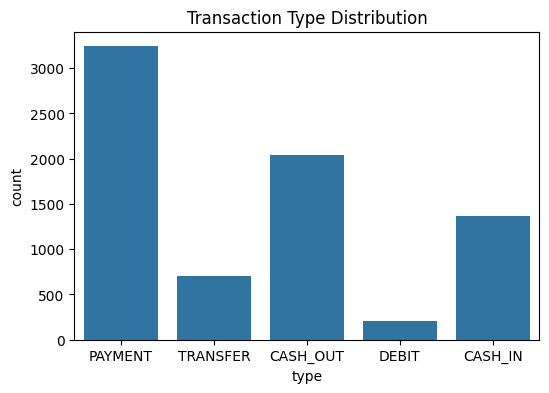

In [6]:
# VISUALIZE TRANSACTION TYPES
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)
plt.title("Transaction Type Distribution")
plt.show()

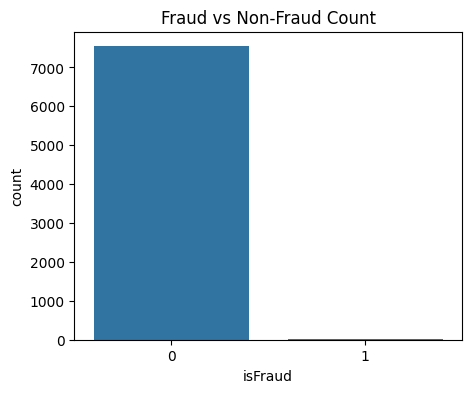

In [7]:
# FRAUD COUNT PLOT
plt.figure(figsize=(5,4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Count")
plt.show()

In [8]:
# FEATURE ENGINEERING
df["errorOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["errorDest"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]



In [9]:
# DROP IRRELEVANT COLUMNS
df = df.drop("step", axis=1)
df = df.drop(["nameOrig", "nameDest",], axis=1)


In [10]:
# ENCODE TRANSACTION TYPE
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [11]:
# REMOVE OUTLIERS (IQR METHOD)
def remove_outliers(data):

    fraud = data[data["isFraud"] == 1]
    normal = data[data["isFraud"] == 0]

    numeric_cols = normal.select_dtypes(include=np.number).columns

    Q1 = normal[numeric_cols].quantile(0.25)
    Q3 = normal[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    mask = ~((normal[numeric_cols] < (Q1 - 1.5 * IQR)) |
             (normal[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

    normal_clean = normal[mask]

    return pd.concat([normal_clean, fraud])


df = remove_outliers(df)
print("\nShape after outlier removal:", df.shape)


Shape after outlier removal: (3836, 13)


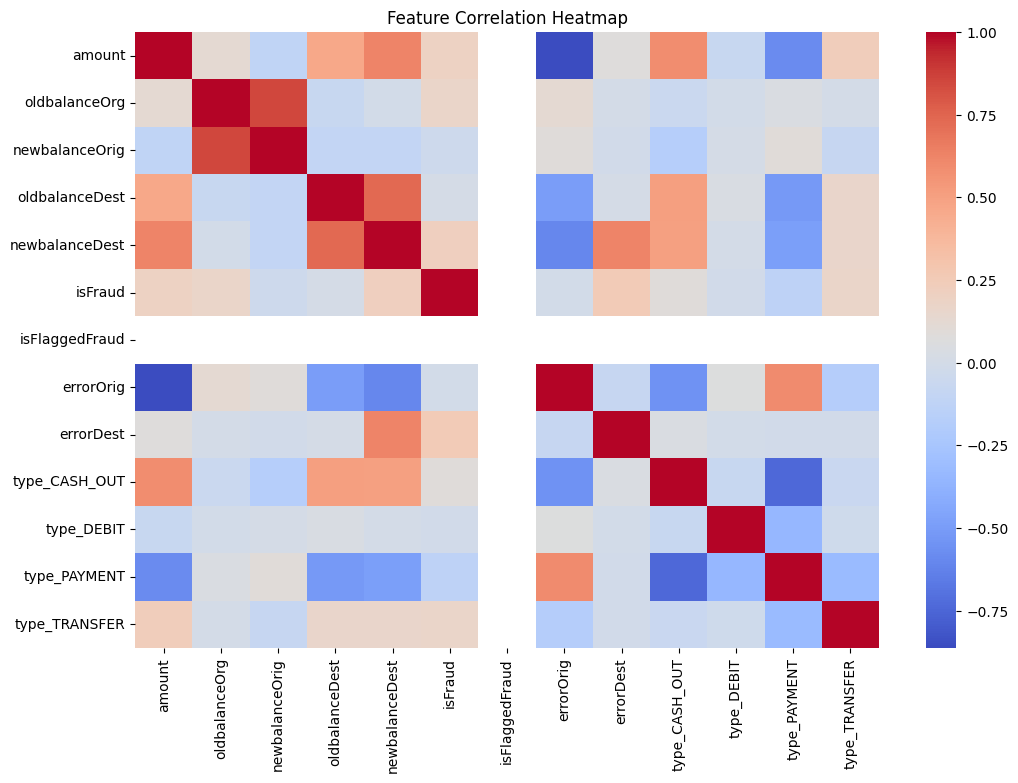

In [12]:
# CORRELATION HEATMAP
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
# SPLIT DATA

X = df.drop("isFraud", axis=1)
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)


In [14]:
# SMOTE BALANCING
print("\nBefore SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train_smote).value_counts())



Before SMOTE:
 isFraud
0    3054
1      14
Name: count, dtype: int64

After SMOTE:
 isFraud
0    3054
1    3054
Name: count, dtype: int64


In [15]:
# SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)



========== MODEL RESULTS ==========

Logistic Regression
Accuracy: 0.9583
ROC-AUC: 0.9791
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       764
           1       0.11      1.00      0.20         4

    accuracy                           0.96       768
   macro avg       0.56      0.98      0.59       768
weighted avg       1.00      0.96      0.97       768



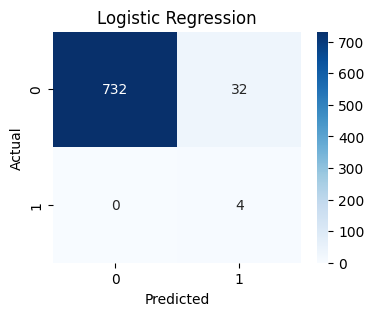


Decision Tree
Accuracy: 0.9987
ROC-AUC: 0.875
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       764
           1       1.00      0.75      0.86         4

    accuracy                           1.00       768
   macro avg       1.00      0.88      0.93       768
weighted avg       1.00      1.00      1.00       768



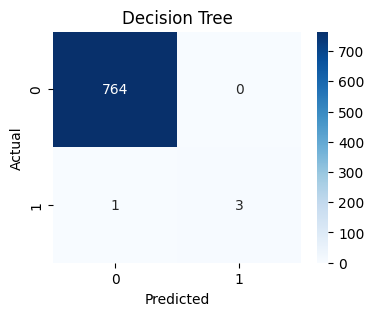


Random Forest
Accuracy: 0.9948
ROC-AUC: 0.873
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       764
           1       0.50      0.75      0.60         4

    accuracy                           0.99       768
   macro avg       0.75      0.87      0.80       768
weighted avg       1.00      0.99      1.00       768



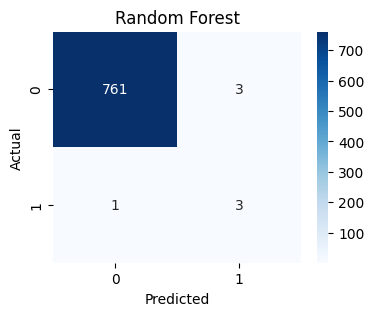

In [16]:
# TRAIN MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=150)
}

results = {}
print("\n========== MODEL RESULTS ==========")
for name, model in models.items():

    model.fit(X_train_scaled, y_train_smote)
    pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    roc = roc_auc_score(y_test, pred)

    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", round(acc,4))
    print("ROC-AUC:", round(roc,4))
    print(classification_report(y_test, pred))
     # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


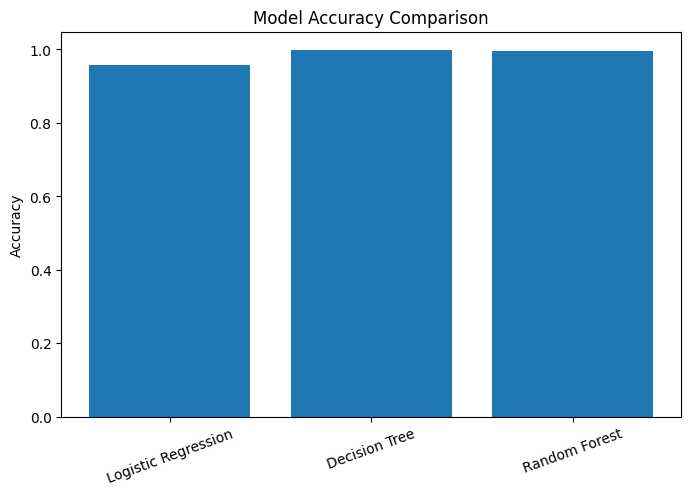

In [17]:
# MODEL COMPARISON GRAPH
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [18]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBEST MODEL:", best_model_name)

best_model.fit(X_train_scaled, y_train_smote)


# =========================
# SAVE MODEL
# =========================
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")


BEST MODEL: Decision Tree
Model saved successfully!
